# 09 Support Vector Machine
Deep Dive möglichst noch ohne Hyperparameter Optimierung. Ziel: Entscheidungsfindung für Modelle

## Import

In [1]:
import time

import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.metrics import roc_auc_score
from sklearn.base import clone
from sklearn.svm import SVC, LinearSVC

import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
mpl.style.use("seaborn-v0_8-colorblind")
RANDOM_STATE = 42

## Dataframe

In [3]:
df_raw = fetch_openml(data_id=42742, as_frame=True).frame

In [4]:
feat_cols = [col for col in df_raw.columns if col not in ("target",)]
cat_cols = [col for col in feat_cols if col.endswith("_cat")]
bin_cols = [col for col in feat_cols if col.endswith("_bin")]
num_cols = [col for col in feat_cols if col not in cat_cols and col not in bin_cols]

for col in cat_cols:
    df_raw[col] = df_raw[col].astype("category")

for col in bin_cols:
    if df_raw[col].isna().sum() == 0:
        df_raw[col] = df_raw[col].astype(int).astype("bool")
    else:
        df_raw[col] = df_raw[col].astype("Int8")

for col in num_cols:
    df_raw[col] = df_raw[col].astype("float32")

df_raw["target"] = df_raw["target"].astype(int).astype("bool")

idx_train = np.load("../../../data/processed/train_idx.npy")
idx_val = np.load("../../../data/processed/val_idx.npy")
idx_test = np.load("../../../data/processed/test_idx.npy")

df_train = df_raw.iloc[idx_train]
df_val = df_raw.iloc[idx_val]
df_test = df_raw.iloc[idx_test]

x_train, y_train = df_train[feat_cols], df_train["target"]
x_val, y_val = df_val[feat_cols], df_val["target"]
x_test, y_test = df_test[feat_cols], df_test["target"]

pd.Series(
    {
        "train": [len(df_train), len(x_train), len(y_train)],
        "val": [len(df_val), len(x_val), len(y_val)],
        "test": [len(df_test), len(x_test), len(y_test)]
    }
)

train    [476168, 476168, 476168]
val         [59522, 59522, 59522]
test        [59522, 59522, 59522]
dtype: object

## Hilfsvariablen

In [25]:
calc_cols = [c for c in feat_cols if c.startswith("ps_calc_")]

mv_cols = ["ps_car_03_cat", "ps_car_05_cat", "ps_reg_03", "ps_car_14"]

num_cols_no_calc = [c for c in num_cols if c not in calc_cols]
bin_cols_no_calc = [c for c in bin_cols if c not in calc_cols]
feat_cols_no_calc = [c for c in feat_cols if c not in calc_cols]

high_kard_cols = ["ps_car_11_cat"]
low_kard_cols = [c for c in cat_cols if c not in high_kard_cols]

bin_cols_one_drop = [c for c in bin_cols if c != "ps_ind_06_bin"]

In [6]:
train_times = {}
results = []

In [11]:
def eval_modell(mod_idx, model, x_train, y_train, x_val, y_val, train_time):
    """AUC auf Train und Val"""
    auc_train = roc_auc_score(y_train, model.decision_function(x_train))
    auc_val = roc_auc_score(y_val, model.decision_function(x_val))
    return {
        "model_idx": mod_idx,
        "auc_train": auc_train,
        "auc_val": auc_val,
        "gini": 2 * auc_val - 1,
        "delta_auc": auc_train - auc_val,
        "trainingszeit": train_time
    }

## L_xgb_01

In [8]:
svm_01 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols
        )
    ),
    LinearSVC(
        max_iter=1000, 
        random_state=RANDOM_STATE
    )
)

In [9]:
name = "L_svm_01"

start_time = time.time()
svm_01.fit(x_train, y_train)
train_times[name] = time.time() - start_time

c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [12]:
results.append(eval_modell(name, svm_01, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,trainingszeit
model_idx,,,,,
L_svm_01,0.6343,0.617425,0.23485,0.016875,46.33875


## L_xgb_02

In [13]:
svm_02 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols
        )
    ),
    LinearSVC(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        C=1.0,
        dual=False,
    )
)

In [14]:
name = "L_svm_02"

start_time = time.time()
svm_02.fit(x_train, y_train)
train_times[name] = time.time() - start_time

c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [15]:
results.append(eval_modell(name, svm_02, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,trainingszeit
model_idx,,,,,
L_svm_01,0.6343,0.617425,0.23485,0.016875,46.338750
L_svm_02,0.6343,0.617425,0.23485,0.016875,44.927721


In [17]:
setsizes = [0.1 ,0.25, 0.5, 0.75, 1.0]
sub_results = []
rng = np.random.default_rng(RANDOM_STATE)

for trainset in setsizes:
    n = int(len(x_train) * trainset)
    idx_sub = rng.permutation(len(x_train))[:n]
    x_sub, y_sub = x_train.iloc[idx_sub], y_train.iloc[idx_sub]

    model = clone(svm_02)
    model.fit(x_sub, y_sub)

    sub_results.append({
        "train_size": n,
        "anteil": trainset,
        "auc_train": roc_auc_score(y_sub, model.decision_function(x_sub)),
        "auc_val": roc_auc_score(y_val, model.decision_function(x_val))
    })

df_sub_results = pd.DataFrame(sub_results)
df_sub_results

c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `

,train_size,anteil,auc_train,auc_val
0,47616,0.10,0.653399,0.602543
1,119042,0.25,0.638446,0.611331
2,238084,0.50,0.634773,0.615177
3,357126,0.75,0.632782,0.616179
4,476168,1.00,0.634245,0.617436


Text(0.5, 1.0, 'Linear SVC Learning Curve')

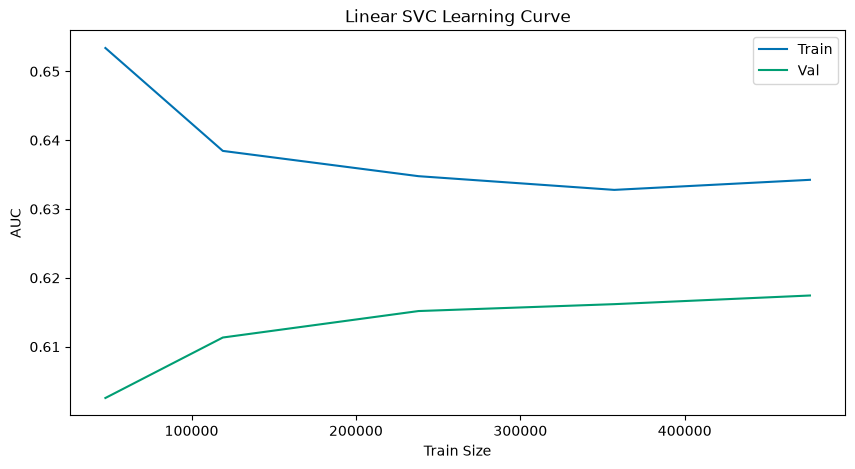

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["auc_train"], label="Train")
ax.plot(df_sub_results["train_size"], df_sub_results["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("Linear SVC Learning Curve")

## L_xgb_03

In [19]:
svm_03 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols
        )
    ),
    LinearSVC(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        C=1.0,
        dual=False,
        class_weight="balanced"
    )
)

In [20]:
name = "L_svm_03"

start_time = time.time()
svm_03.fit(x_train, y_train)
train_times[name] = time.time() - start_time

c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [21]:
results.append(eval_modell(name, svm_03, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,trainingszeit
model_idx,,,,,
L_svm_01,0.634300,0.617425,0.234850,0.016875,46.338750
L_svm_02,0.634300,0.617425,0.234850,0.016875,44.927721
L_svm_03,0.635508,0.617228,0.234456,0.018280,78.952868


## L_xgb_04

In [22]:
svm_04 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols
        )
    ),
    LinearSVC(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        C=1.0,
        dual=False,
    )
)

In [23]:
name = "L_svm_04"

start_time = time.time()
svm_04.fit(x_train, y_train)
train_times[name] = time.time() - start_time

c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [24]:
results.append(eval_modell(name, svm_04, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,trainingszeit
model_idx,,,,,
L_svm_01,0.634300,0.617425,0.234850,0.016875,46.338750
L_svm_02,0.634300,0.617425,0.234850,0.016875,44.927721
L_svm_03,0.635508,0.617228,0.234456,0.018280,78.952868
L_svm_04,0.634309,0.617412,0.234824,0.016896,32.337762


In [ ]:
svm_04MK2 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols_one_drop
        )
    ),
    LinearSVC(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        C=1.0,
        dual=False,
    )
)

In [27]:
name = "L_svm_04MK2"

start_time = time.time()
svm_04MK2.fit(x_train, y_train)
train_times[name] = time.time() - start_time

c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [28]:
results.append(eval_modell(name, svm_04MK2, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,trainingszeit
model_idx,,,,,
L_svm_01,0.634300,0.617425,0.234850,0.016875,46.338750
L_svm_02,0.634300,0.617425,0.234850,0.016875,44.927721
L_svm_03,0.635508,0.617228,0.234456,0.018280,78.952868
L_svm_04,0.634309,0.617412,0.234824,0.016896,32.337762
L_svm_04MK2,0.634311,0.617419,0.234837,0.016892,32.385512


## L_xgb_05

In [29]:
transformer_05 = make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols
        )
    )

In [ ]:
svm_05 = make_pipeline(
    transformer_05,
    StandardScaler(),
    LinearSVC(
            max_iter=1000, 
            random_state=RANDOM_STATE,
            C=1.0,
            dual=False
    )
)

In [31]:
name = "L_svm_05"

start_time = time.time()
svm_05.fit(x_train, y_train)
train_times[name] = time.time() - start_time

c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [32]:
results.append(eval_modell(name, svm_05, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,trainingszeit
model_idx,,,,,
L_svm_01,0.634300,0.617425,0.234850,0.016875,46.338750
L_svm_02,0.634300,0.617425,0.234850,0.016875,44.927721
L_svm_03,0.635508,0.617228,0.234456,0.018280,78.952868
L_svm_04,0.634309,0.617412,0.234824,0.016896,32.337762
L_svm_04MK2,0.634311,0.617419,0.234837,0.016892,32.385512
L_svm_05,0.634318,0.617418,0.234835,0.016900,12.833897


## L_svm_06

In [33]:
svm_06 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols_no_calc
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols_no_calc
        )
    ),
    LinearSVC(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        C=1.0,
        dual=False,
    )
)

In [34]:
name = "L_svm_06"

start_time = time.time()
svm_06.fit(x_train, y_train)
train_times[name] = time.time() - start_time

c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [35]:
results.append(eval_modell(name, svm_06, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,trainingszeit
model_idx,,,,,
L_svm_01,0.634300,0.617425,0.234850,0.016875,46.338750
L_svm_02,0.634300,0.617425,0.234850,0.016875,44.927721
L_svm_03,0.635508,0.617228,0.234456,0.018280,78.952868
L_svm_04,0.634309,0.617412,0.234824,0.016896,32.337762
L_svm_04MK2,0.634311,0.617419,0.234837,0.016892,32.385512
L_svm_05,0.634318,0.617418,0.234835,0.016900,12.833897
L_svm_06,0.634145,0.617920,0.235840,0.016225,20.472512


## Notizen
Punkte aus der EDA, die ich hier behandeln möchte:
|Gedanke|Umsetzung|
|---|---|
|One Hot Kolineartät|drop first und möglicherweise ps_ind_06_bin|
|ps_calc_* mkaum signal|drop möglich|
|Klassenimbalance|calss weight balanced|

Punkte aus der Aufgabenstellung, die ich hier behandeln möchte:
- Learning Curve vor Modelltraining

Modelle im Notebook:
|Modell Index|Spezifikation
|---|---|
|L_svm_01|Simple aus 06 als Bezugspunkt|
|L_svm_02|Mit besserer Kapazität(C, dual)|
|L_svm_03|class weight balanced|
|L_svm_04|drop first in bis jetzt bestes (mk 2 mit drop ps_ind_06_bin wie in 07)|
|L_svm_05|scaler auf allem laufen lassen --> weniger hochvarianz|
|L_svm_06|calc drop auf bisher bestem|


- SVC hat kein predict_proba
- also decision function in eval


- Hsu, C. W., Chang, C. C., & Lin, C. J. (2003). A practical guide to support vector classification.
